In [1]:
# Hyper-EZ Demo

## Clone required repositories
!git clone https://github.com/naikp13/hyper-ez.git && cd hyper-ez && pip install -r requirements.txt
!git clone https://github.com/naikp13/hyEnhance.git

Cloning into 'hyper-ez'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 23 (delta 7), reused 11 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 14.99 KiB | 5.00 MiB/s, done.
Resolving deltas: 100% (7/7), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.8/206.8 kB 15.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-contrib-python
    Found existing installation: opencv-contrib-python 4.12.0.88
    Uninstalling opencv-contrib-python-4.12.0.88:
      Successfully uninstalled opencv-contrib-python-4.12.0.88
Cloning into 'hsi_enhancement'...
remote: Enumerating objects: 206, done.
remote: Counting objects: 100% (73/73), done.
remote:

In [2]:
# Import required packages

from google.colab import drive
drive.mount("/content/drive/", force_remount = True)
import sys; sys.path.append('/content/hyper-ez')
from google.colab import files
from hyper_ez import *

Mounted at /content/drive/


In [7]:
# Upload hyperspectral image

print("Upload your Low-Resolution Hyperspectral Image")

# Direct file path input
hsi_path = input("Enter path to your .tif file: ")

Upload your Low-Resolution Hyperspectral Image
Enter path to your .tif file: /content/drive/MyDrive/pansharpen/enmap_marinkas.tif


In [8]:
# Get target date
target_date = input("Enter the date of acquisition  (YYYY-MM-DD): ")

Enter the date of acquisition  (YYYY-MM-DD): 2024-07-20


In [9]:
# Initialize processors
setup_matplotlib_style()
data_acq = SatelliteDataAcquisition()
geo_proc = GeospatialProcessor()
hsi_proc = HyperspectralProcessor()
visualizer = HyperspectralVisualizer()

# Extract metadata and search satellite data
roi, bounds, crs, res = geo_proc.extract_spatial_metadata(hsi_path)
sentinel_item = data_acq.search_sentinel2_data(roi, target_date)
print(f"Found Sentinel-2: {sentinel_item.id} ({sentinel_item.properties['eo:cloud_cover']}% clouds)")

Found Sentinel-2: S2A_33JYJ_20240716_0_L2A (0.394939% clouds)


In [10]:
# Process and enhance
bands = geo_proc.process_sentinel2_bands(sentinel_item, bounds, crs)
geo_proc.stack_bands_to_multiband(bands, 'sentinel.tif')
esri_path = hsi_proc.acquire_high_resolution_imagery(bounds, crs)
hsi_enhanced = hsi_proc.enhance_hyperspectral_image('sentinel.tif', hsi_path)
hsi_proc.save_enhanced_data(hsi_enhanced, 'sentinel.tif', 'temp_enhanced.tif')
hsi_super = hsi_proc.enhance_hyperspectral_image(esri_path, 'temp_enhanced.tif')

/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
Processing patches: 100%|██████████| 41830/41830 [01:34<00:00, 444.09it/s]


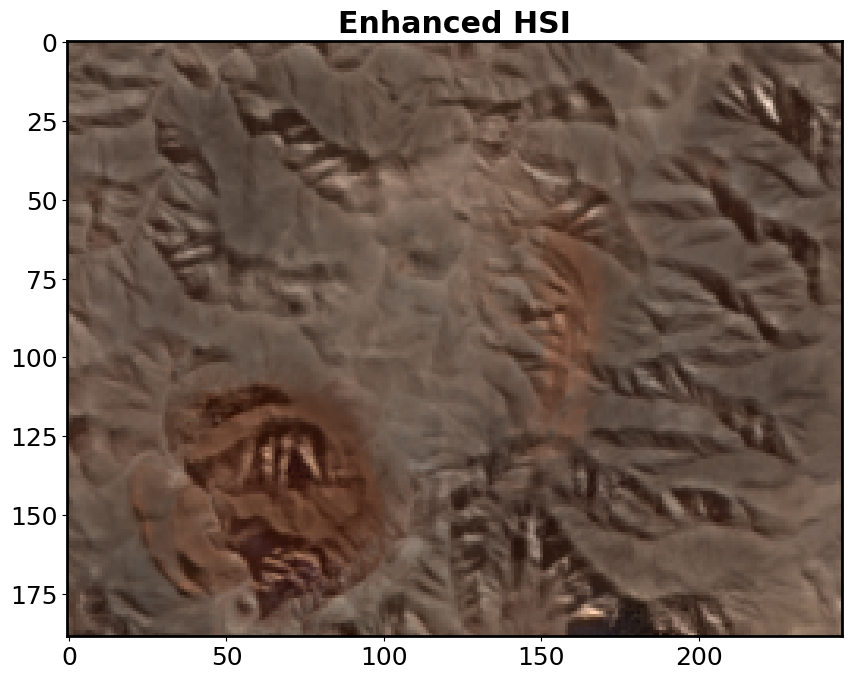

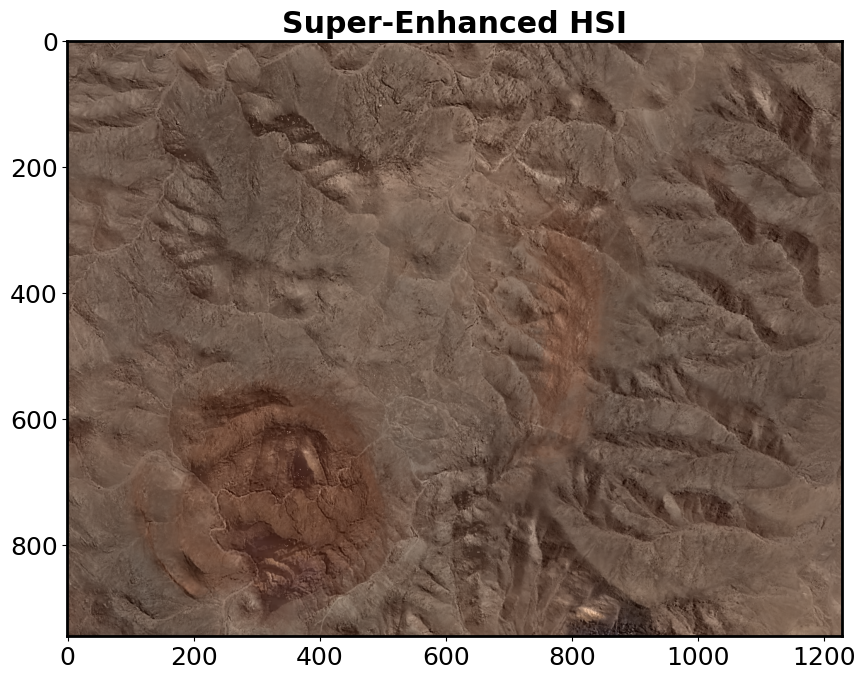

Enhanced: (189, 246, 219), Super-Enhanced: (945, 1230, 219)


In [11]:
# Display results
visualizer.display_false_color_composite(hsi_enhanced, "Enhanced HSI")
visualizer.display_false_color_composite(hsi_super, "Super-Enhanced HSI")
print(f"Enhanced: {hsi_enhanced.shape}, Super-Enhanced: {hsi_super.shape}")